# Common Libraries

In [2]:
import os, sys, shutil, mediapy
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pylab as plt
from ipywidgets import interact

if shutil.which("nvidia-smi") is not None:
    os.environ["MUJOCO_GL"] = "egl"
import mujoco

# Custom Libraries

In [3]:
def get_indices(model, joint_name):
    jnt_id = model.joint(joint_name).id
    qpos_idx = model.jnt_qposadr[jnt_id]
    dof_idx = model.jnt_dofadr[jnt_id]
    return qpos_idx, dof_idx

In [4]:
def get_qfrc(model, data, target_qpos):
    """
    Compute the generalized force needed to reach the target position in the next mujoco step.
    """
    data_copy = mujoco.MjData(model)
    data_copy.qpos = data.qpos.copy()
    data_copy.qvel = data.qvel.copy()
    data_copy.qacc = (((target_qpos - data.qpos) / model.opt.timestep) - data.qvel) / model.opt.timestep
    #model.opt.disableflags += mujoco.mjtDisableBit.mjDSBL_CONSTRAINT
    mujoco.mj_inverse(model, data_copy)
    #model.opt.disableflags -= mujoco.mjtDisableBit.mjDSBL_CONSTRAINT
    return data_copy.qfrc_inverse

# Params

In [5]:
model_path = "/Users/seojin/myo_sim/arm/myoarm.xml"

# Initialize model

In [14]:
model = mujoco.MjModel.from_xml_path(model_path)
sim_interval = model.opt.timestep

# Model constants
joint_names = [mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_JOINT, idx) for idx in range(model.njnt)]
n_joint = len(joint_names)

# Joint indexing
shoulder_elevation_angle_q, shoulder_elevation_angle_d = get_indices(model, "shoulder_elv")

# Initialize pose
mj_data = mujoco.MjData(model)
mujoco.mj_forward(model, mj_data)

# Renderer

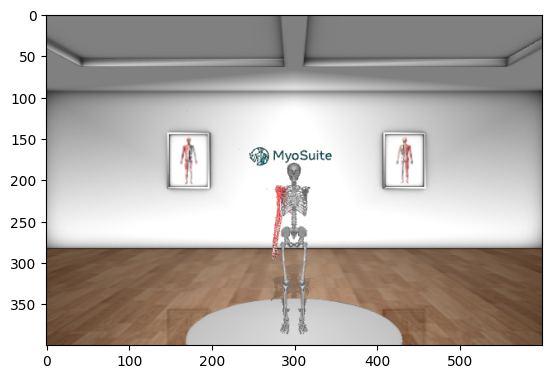

In [7]:
# Renderer
renderer = mujoco.Renderer(model, height=400, width=600)
scene_option = mujoco.MjvOption()
scene_option.frame = mujoco.mjtFrame.mjFRAME_WORLD

# Camera
camera = mujoco.MjvCamera()
camera.azimuth = 90
camera.elevation = 0
camera.distance = 4
camera.lookat = [0,0,1.5]

# Initial render
renderer.update_scene(mj_data, camera=camera, scene_option=scene_option)
plt.imshow(renderer.render())

# Goal

In [8]:
final_goal_qpos = mj_data.qpos.copy()
final_goal_qpos[shoulder_elevation_angle_q] = 1.6

In [12]:
n_sim = 100

In [15]:
sim_interval

0.002

# Simulate shoulder elevation

In [ ]:
n_times = 2

# Initialize start pose
mj_data = mujoco.MjData(model)
mujoco.mj_forward(model, mj_data)

# Goal
final_goal_qpos = mj_data.qpos.copy()
final_goal_qpos[shoulder_elevation_angle_q] = 1.6

# Image
pixels = np.zeros((n_times, renderer.height, renderer.width, 3), dtype = np.uint8)

# Force
qforces = pd.DataFrame(np.zeros((n_times, n_joint)))
qforces.columns = joint_names

# Error
qerrors = pd.DataFrame(np.zeros((n_times, n_joint)))
qerrors.columns = joint_names

# Simulation
for time_i in tqdm(range(n_times)):
    # Current
    current_qpos = mj_data.qpos.copy()
    current_qvel = mj_data.qvel.copy()
    
    # Control
    error_q = np.zeros(n_joint)
    error_q[shoulder_elevation_angle_q] = final_goal_qpos[shoulder_elevation_angle_q] - current_qpos[shoulder_elevation_angle_q]
    qerrors.iloc[time_i] = error_q

    # mj inverse
    tau_all = get_qfrc(model, mj_data, final_goal_qpos)    
    mj_data.qfrc_applied[:] = tau_all
    qforces.iloc[time_i] = tau_all

    # Forward dyanmics
    mujoco.mj_step(model, mj_data)

    # Rendering
    renderer.update_scene(mj_data, camera = camera, scene_option = scene_option)
    pixels[time_i] = renderer.render()

100%|█████████████████████████████████████████████| 2/2 [00:00<00:00, 18.54it/s]


In [33]:
mediapy.show_video(pixels, fps = 1, loop=False)

This browser does not support the video tag.


In [34]:
qforces

,sternoclavicular_r2,sternoclavicular_r3,unrotscap_r3,unrotscap_r2,acromioclavicular_r2,acromioclavicular_r3,acromioclavicular_r1,unrothum_r1,unrothum_r3,unrothum_r2,...,pm3_flexion,md3_flexion,mcp4_flexion,mcp4_abduction,pm4_flexion,md4_flexion,mcp5_flexion,mcp5_abduction,pm5_flexion,md5_flexion
0,-7996.998485,570338.836078,578208.932552,-17686.791539,-105157.048143,460447.574425,-347102.879901,-338901.106447,447641.478955,-106729.394064,...,-96.129545,-39.930455,-164.315031,91.270072,-84.002857,-31.625795,-121.467729,93.836342,-67.639033,-23.977481
1,10026.954866,-589712.750562,-547288.054072,44543.714035,136125.675673,-479995.475036,374501.761465,355178.061606,-458061.504121,132459.070843,...,97.347612,40.139881,165.031567,-103.122400,84.730237,31.820256,123.773430,-105.381114,68.528726,24.128038


# Simulate elevation angle

In [24]:
# Initialize start pose
mj_data = mujoco.MjData(model)
mujoco.mj_forward(model, mj_data)

# Goal
final_goal_qpos = mj_data.qpos.copy()
final_goal_qpos[elevation_angle_q] = 1.5708

# Image
pixels = np.zeros((n_times, renderer.height, renderer.width, 3), dtype = np.uint8)

# Force
qforces = pd.DataFrame(np.zeros((n_times, n_joint)))
qforces.columns = joint_names

# Error
qerrors = pd.DataFrame(np.zeros((n_times, n_joint)))
qerrors.columns = joint_names

# Simulation
for time_i in tqdm(range(n_times)):
    # Current
    current_qpos = mj_data.qpos.copy()
    current_qvel = mj_data.qvel.copy()
    
    # Control
    error_q = np.zeros(n_joint)
    error_q[elevation_angle_q] = final_goal_qpos[elevation_angle_q] - current_qpos[elevation_angle_q]
    qerrors.iloc[time_i] = error_q

    # Force
    tau_all = get_qfrc(model, mj_data, final_goal_qpos)    
    mj_data.qfrc_applied[:] = tau_all
    qforces.iloc[time_i] = tau_all

    # Forward dyanmics
    mujoco.mj_step(model, mj_data)

    # Rendering
    renderer.update_scene(mj_data, camera = camera, scene_option = scene_option)
    pixels[time_i] = renderer.render()

100%|█████████████████████████████████████████████| 2/2 [00:00<00:00, 21.12it/s]


In [25]:
mediapy.show_video(pixels, fps = 1, loop=False)

This browser does not support the video tag.
